# f7 Mor descriptors → 1–3 dimensions (slow, step-by-step)

Group **f7_surface_shape_Mor** uses all Dragon columns whose names start with **`Mor`** (about 223 in your matrix).

We use **PCA** (principal component analysis) after **standardizing** each column. That is the usual first approach: it finds new axes that capture as much *combined variance* as possible.

**Requirement:** `data/waka_dragon_merged.csv` (Wakayama + Dragon merged by CID). If the file is missing, build it from your preprocess notebook first.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Step 0: load your table ---
csv_path = Path("data/waka_dragon_merged.csv")
if not csv_path.is_file():
    raise FileNotFoundError(
        f"Put your merged file here: {csv_path.resolve()}"
    )

df = pd.read_csv(csv_path)
print("rows, cols:", df.shape)

rows, cols: (312, 2499)


### Step 1 — Keep only Mor columns

We match the same rule as in `features_set_1.ipynb`: column names starting with **`Mor`**.

In [3]:
mor_cols = [c for c in df.columns if c.startswith("Mor")]
print("number of Mor descriptors:", len(mor_cols))

X = df[mor_cols].apply(pd.to_numeric, errors="coerce")
# drop rows where every Mor value is missing (if any)
X = X.dropna(how="all")
print("samples after dropna(all):", len(X))

number of Mor descriptors: 223
samples after dropna(all): 288


### Step 2 — Standardize

Descriptors have different scales. PCA is usually run on **z-scores** (mean 0, variance 1 per column).

In [4]:
X_filled = X.fillna(X.median(numeric_only=True))
scaler = StandardScaler()
Xz = scaler.fit_transform(X_filled)
print("scaled matrix shape:", Xz.shape)

scaled matrix shape: (288, 223)


### Step 3 — How many PCA components explain the data?

We fit PCA with many components **only** to draw a curve: how much variance the first 1, 2, 3, … components capture.

- **PC1**: direction of largest variance.
- **PC2**, **PC3**: next directions, orthogonal to the previous ones.

If PC1–PC3 together explain e.g. 40–70% of variance, that is normal for many correlated chemistry descriptors; going to 1–3 dimensions always loses detail—the curve helps you see *how much*.

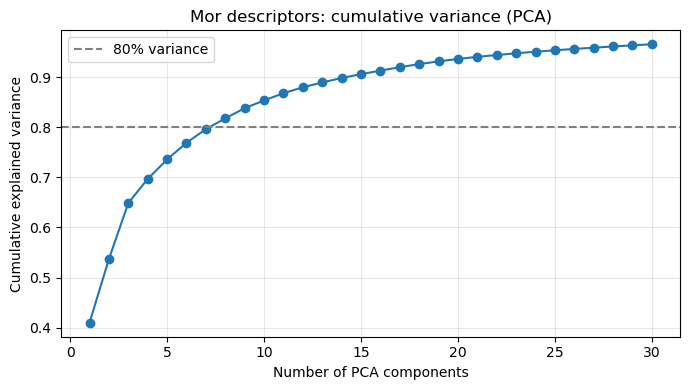

First 1 PC(s) explain 41.0% of variance
First 2 PC(s) explain 53.7% of variance
First 3 PC(s) explain 64.9% of variance


In [5]:
n_samples, n_features = Xz.shape
# PCA cannot use more components than min(n_samples, n_features)
n_pca = min(30, n_samples - 1, n_features)

pca_explore = PCA(n_components=n_pca, random_state=0)
pca_explore.fit(Xz)

var_ratio = pca_explore.explained_variance_ratio_
cumsum = var_ratio.cumsum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumsum) + 1), cumsum, marker="o")
ax.axhline(0.8, color="gray", linestyle="--", label="80% variance")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Mor descriptors: cumulative variance (PCA)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k in (1, 2, 3):
    print(f"First {k} PC(s) explain {cumsum[k-1]*100:.1f}% of variance")

### Step 4 — Build 1, 2, or 3 columns you can use as features

Below we fit PCA with **3** components. Use only **PC1** if you want one dimension; **PC1–PC2** for two; all three for 3D.

**Naming:** `Mor_PC1`, `Mor_PC2`, `Mor_PC3` — easy to merge back with `CID` if you keep the same row order as `X`.

In [6]:
n_keep = 3
pca3 = PCA(n_components=n_keep, random_state=0)
scores = pca3.fit_transform(Xz)

mor_scores = pd.DataFrame(
    scores,
    columns=[f"Mor_PC{i+1}" for i in range(n_keep)],
    index=X.index,
)

# Attach CID if present and indices still align
if "CID" in df.columns:
    mor_scores.insert(0, "CID", df.loc[X.index, "CID"].values)

mor_scores.head()

,CID,Mor_PC1,Mor_PC2,Mor_PC3
0,179,8.511180,-9.235072,-5.318483
1,240,14.924735,-2.799486,0.464463
2,244,15.580128,-1.793474,0.676599
3,323,16.755100,2.373415,0.789718
4,326,9.112084,0.745566,0.794729


### Step 5 (optional) — Which original Mor columns drive PC1?

Large absolute **loading** = that descriptor contributes strongly to that component. This helps interpretation.

In [7]:
loadings = pd.DataFrame(
    pca3.components_.T,
    index=mor_cols,
    columns=[f"Mor_PC{i+1}" for i in range(n_keep)],
)

pc1_top = loadings["Mor_PC1"].abs().sort_values(ascending=False).head(15)
print("Top 15 |loading| on Mor_PC1:")
print(loadings.loc[pc1_top.index, "Mor_PC1"])

Top 15 |loading| on Mor_PC1:
Mor12p    0.100233
Mor31p   -0.099465
Mor31v   -0.099380
Mor12v    0.099345
Mor19p   -0.098657
Mor19v   -0.097730
Mor19u   -0.097673
Mor19e   -0.097550
Mor14v   -0.097057
Mor14p   -0.096799
Mor19i   -0.096492
Mor31u   -0.096368
Mor31e   -0.096148
Mor31m   -0.095768
Mor14m   -0.095366
Name: Mor_PC1, dtype: float64


---

**Short recap**

1. **StandardScaler** → fair PCA.
2. **Scree / cumulative plot** → decide if 1–3 PCs are acceptable for your goal.
3. **`Mor_PC1`…`Mor_PC3`** → your reduced features; interpret with loadings.

Other methods (t-SNE, UMAP) are mainly for **visualization**, not stable feature columns for modeling—PCA is the usual starting point for “223 → a few numeric features.”